# Time Series Foundations

## What is a Time Series?

A **time series** is a sequence of data points collected or recorded at time intervals, usually equally spaced. It captures how something changes over time.

### Real-World Examples:
- Stock prices recorded daily
- Monthly airline passengers
- Hourly temperature data
- Weekly sales from an e-commerce platform



## Components of a Time Series

1. **Trend**: Long-term increase or decrease in the data
2. **Seasonality**: Repeating patterns at regular intervals (e.g., daily, monthly)
3. **Noise (Residual)**: Irregular fluctuations not explained by trend/seasonality

---

## Additive vs Multiplicative Models

- **Additive Model**:  
  \[
  Y(t) = T(t) + S(t) + R(t)
  \]  
  Trend, Seasonality, and Residual add together.

- **Multiplicative Model**:  

  Y(t) = T(t) * S(t) * R(t)
   
  Components multiply together; seasonality grows with trend.

### Visual Intuition:

| Model Type      | Suitable For                      |
|-----------------|-----------------------------------|
| Additive        | Stable seasonality (e.g., temperature) |
| Multiplicative  | Increasing seasonal variation (e.g., retail sales) |


In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

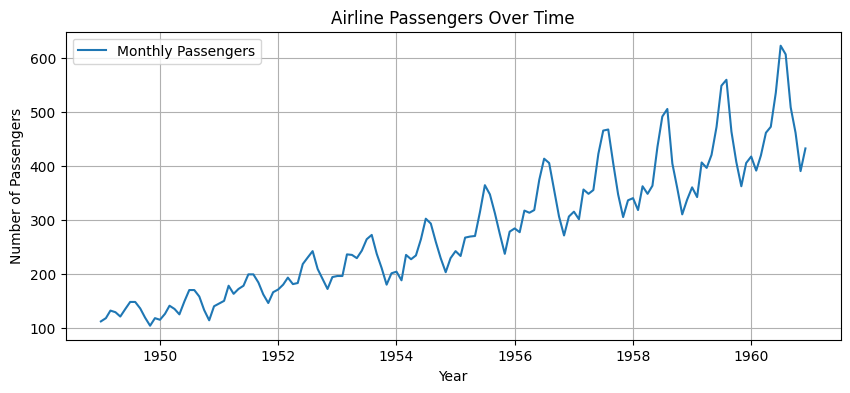

In [ ]:



# 📁 Load dataset: Monthly Airline Passengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# 📈 Plotting the time series
plt.figure(figsize=(10, 4))
plt.plot(df, label='Monthly Passengers')
plt.title('Airline Passengers Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()


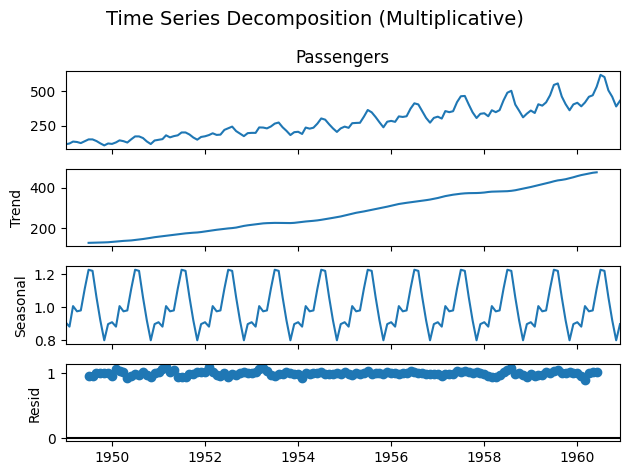

In [ ]:
# ⚙️ Decompose the time series (multiplicative)
result = seasonal_decompose(df['Passengers'], model='multiplicative')

# 📉 Plot decomposition
result.plot()
plt.suptitle('Time Series Decomposition (Multiplicative)', fontsize=14)
plt.tight_layout()
plt.show()


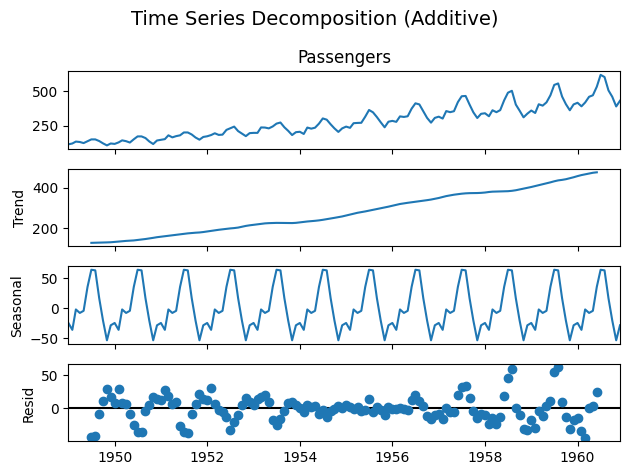

In [ ]:
# ⚙️ Decompose the time series (additive)
result = seasonal_decompose(df['Passengers'], model='additive')

# 📉 Plot decomposition
result.plot()
plt.suptitle('Time Series Decomposition (Additive)', fontsize=14)
plt.tight_layout()
plt.show()


#  Forecasting

---

## 1. Why Forecasting?

- Helps predict future trends based on historical data.
- Important in:
  - Demand planning
      - Predict how many products customers will buy
      - Helps avoid stockouts or overproduction
  - Budgeting
      - Estimate future revenues and expenses
      - Helps plan investments and resource allocation
  - Inventory management
      - Maintain optimal stock levels
      - Reduces storage cost and wastage
  - Stock trading
      - Identify trends or seasonality
      - Traders use forecasts for timing buy/sell decisions







## Moving Average – Simple Forecasting


The **Moving Average (MA)** method smooths out short-term fluctuations and highlights longer-term trends in time series data.

It works by **averaging the most recent *n* observations**.


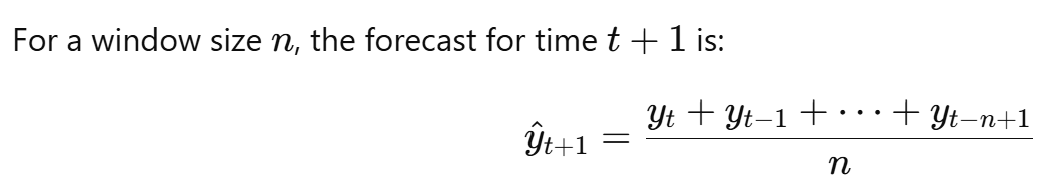

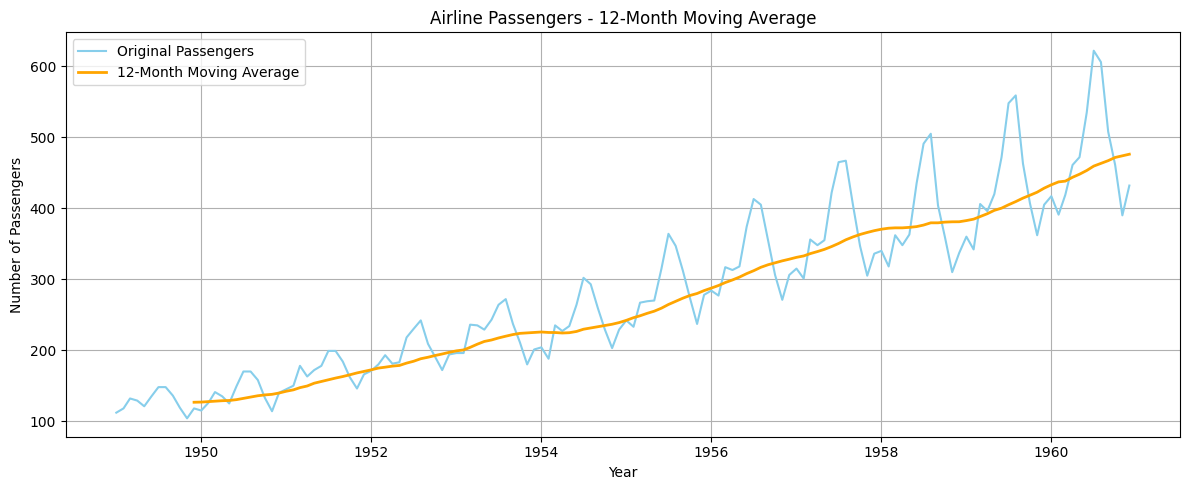

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt


# Apply 12-month Moving Average (to smooth yearly seasonality)
df['MA_12'] = df['Passengers'].rolling(window=12).mean()

# Plot original data and moving average
plt.figure(figsize=(12, 5))
plt.plot(df['Passengers'], label='Original Passengers', color='skyblue')
plt.plot(df['MA_12'], label='12-Month Moving Average', color='orange', linewidth=2)
plt.title('Airline Passengers - 12-Month Moving Average')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-5-dd1845a664b6>:37: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


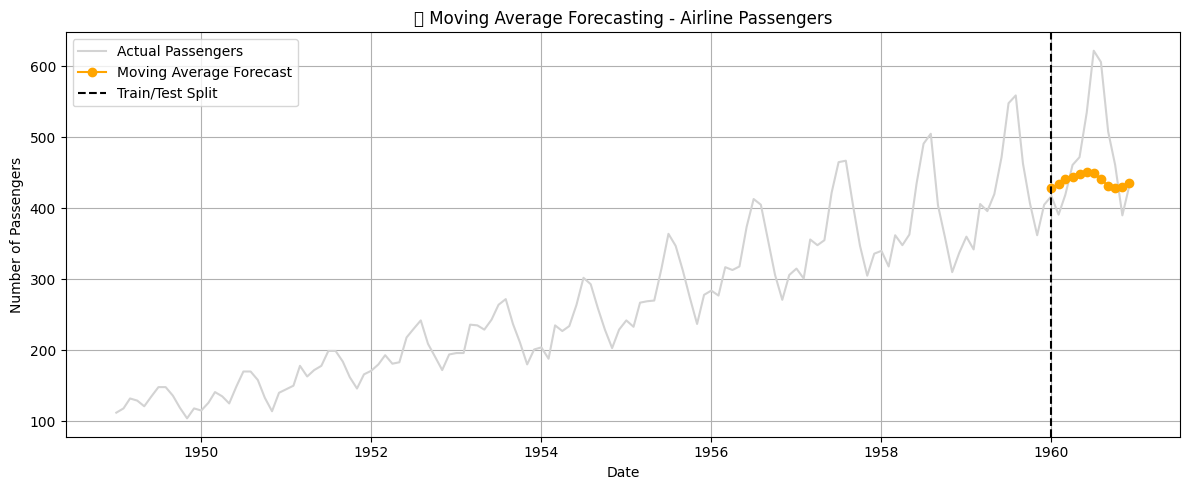

In [ ]:




#  Train-Test Split (last 12 months for testing)
train = df.iloc[:-12]
test = df.iloc[-12:]

# Apply Moving Average on train data
window_size = 12
train.loc[:, 'MA_12'] = train['Passengers'].rolling(window=window_size).mean()

#  Forecast: Use last 12-month average as forecast for test period
# We'll use the last window from train to predict each test point
last_window = train['Passengers'][-window_size:].values

predictions = []
for i in range(len(test)):
    forecast = np.mean(last_window)
    predictions.append(forecast)
    # Optional: update the window with the new forecast
    last_window = np.append(last_window[1:], forecast)

# Plot the results
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Passengers'], label='Actual Passengers', color='lightgray')
plt.plot(test.index, predictions, label='Moving Average Forecast', color='orange', marker='o')
plt.axvline(test.index[0], color='black', linestyle='--', label='Train/Test Split')
plt.title('Moving Average Forecasting - Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#  1. Simple Exponential Smoothing (SES)

---

##  Theory

- Simple Exponential Smoothing is used when the time series has **no trend and no seasonality**.
- It applies exponentially decreasing weights to past observations.
- **Recent observations** are weighted more heavily.
- Useful for stable series without trend or seasonality.

---

##  Formula


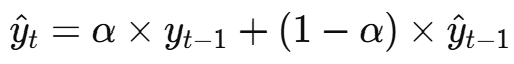

Where:
- ŷₜ = forecast for time t
- yₜ₋₁ = actual value at time t-1
- ŷₜ₋₁ = forecasted value at time t-1
- α = smoothing factor (0 < α < 1)

 If α is closer to 1 → focus more on recent observations.  
 If α is closer to 0 → focus more on older observations.


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


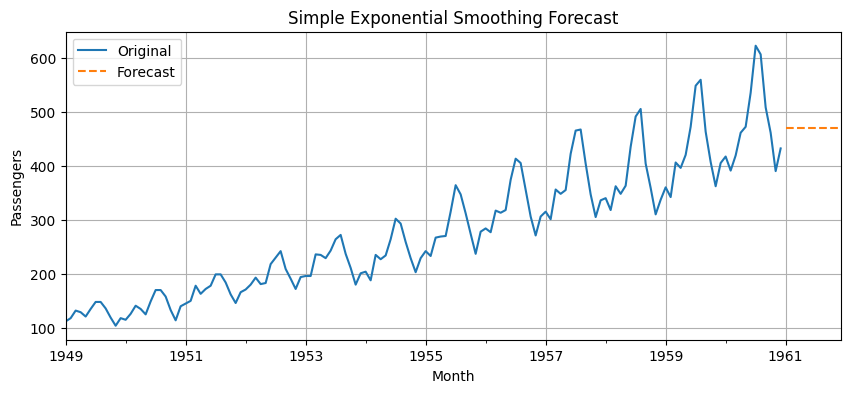

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Load Airline Passenger Data
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Apply Simple Exponential Smoothing
model = SimpleExpSmoothing(df['Passengers'])
model_fit = model.fit(smoothing_level=0.2, optimized=False)  # smoothing_level can be tuned
forecast = model_fit.forecast(steps=12)

# Plot the results
plt.figure(figsize=(10, 4))
df['Passengers'].plot(label='Original')
forecast.plot(label='Forecast', linestyle='--')
plt.title('Simple Exponential Smoothing Forecast')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()


# 2. Double Exponential Smoothing (Holt’s Method) with Train-Test Split

---

##  Theory

- Double Exponential Smoothing is useful when the series has a **trend** but **no seasonality**.

---

##  Formula

Level:  
ℓₜ = α × yₜ + (1 - α) × (ℓₜ₋₁ + bₜ₋₁)

Trend:  
bₜ = β × (ℓₜ - ℓₜ₋₁) + (1 - β) × bₜ₋₁

Forecast:  
ŷₜ₊ₕ = ℓₜ + h × bₜ

Where:
- ℓₜ = level estimate
- bₜ = trend estimate
- ŷₜ₊ₕ = forecast for h steps ahead


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


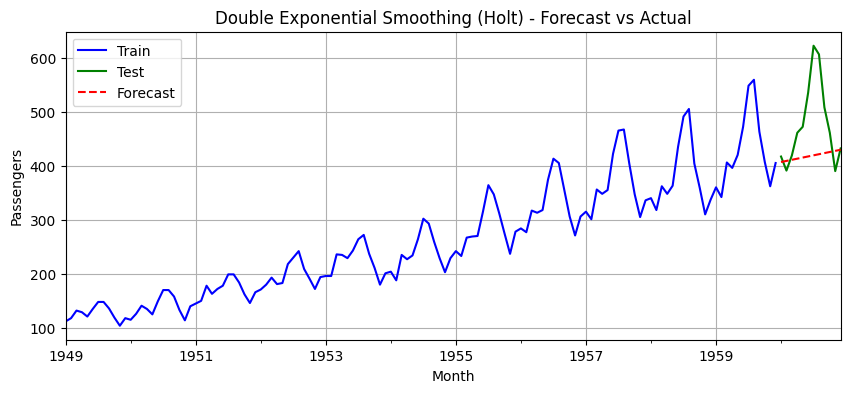

In [ ]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load Airline Passenger Data
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Train-Test Split
train = df.iloc[:-12]
test = df.iloc[-12:]

# Fit Holt’s Model (trend only, no seasonality)
model = ExponentialSmoothing(train['Passengers'], trend='add', seasonal=None)
model_fit = model.fit()

# Forecast the next 12 months (length of test)
forecast = model_fit.forecast(steps=12)

# Plot: Forecast vs Actual
plt.figure(figsize=(10, 4))
train['Passengers'].plot(label='Train', color='blue')
test['Passengers'].plot(label='Test', color='green')
forecast.plot(label='Forecast', linestyle='--', color='red')
plt.title('Double Exponential Smoothing (Holt) - Forecast vs Actual')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()



#  3. Holt-Winters Method (Triple Exponential Smoothing)

---

## Theory

- Holt-Winters extends exponential smoothing to handle:
  - **Level**
  - **Trend**
  - **Seasonality**

- Suitable for time series that show **trend + seasonal patterns**.

- There are two types:
  - **Additive**: seasonality has constant magnitude
  - **Multiplicative**: seasonality grows with the trend

---

## Formula

Level:  
ℓₜ = α × (yₜ / sₜ₋ₘ) + (1 - α) × (ℓₜ₋₁ + bₜ₋₁)

Trend:  
bₜ = β × (ℓₜ - ℓₜ₋₁) + (1 - β) × bₜ₋₁

Seasonality (Multiplicative):  
sₜ = γ × (yₜ / ℓₜ) + (1 - γ) × sₜ₋ₘ

Forecast:  
ŷₜ₊ₕ = (ℓₜ + h × bₜ) × sₜ₋ₘ₊ₕ

Where:
- ℓₜ = level at time t
- bₜ = trend at time t
- sₜ = seasonal component
- m = season length (e.g., 12 for monthly)
- α, β, γ = smoothing parameters


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


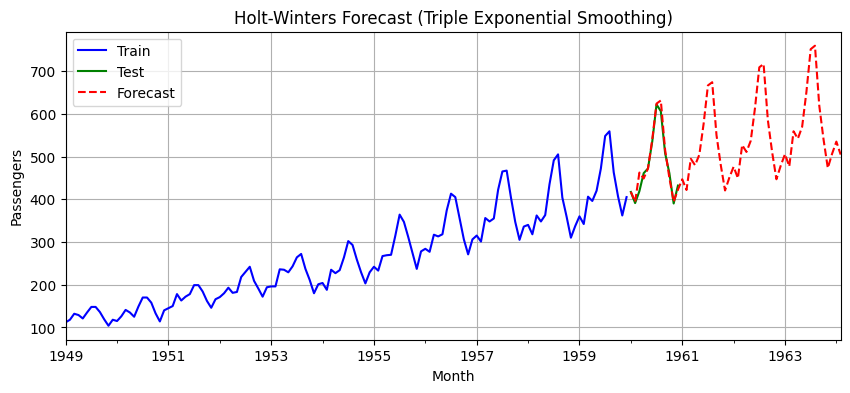

In [ ]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load Airline Passenger Data
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Train-Test Split
train = df.iloc[:-12]
test = df.iloc[-12:]

# Holt-Winters Model (with seasonal pattern)
model = ExponentialSmoothing(train['Passengers'],
                              trend='add',
                              seasonal='mul',
                              seasonal_periods=12)
model_fit = model.fit()

# Forecast the test period
forecast = model_fit.forecast(steps=50)

# Plotting
plt.figure(figsize=(10, 4))
train['Passengers'].plot(label='Train', color='blue')
test['Passengers'].plot(label='Test', color='green')
forecast.plot(label='Forecast', linestyle='--', color='red')
plt.title('Holt-Winters Forecast (Triple Exponential Smoothing)')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()




---

## ✅ 1. What is Stationarity?

A stationary time series has:

- Constant mean  
- Constant variance  
- Constant autocorrelation structure  

📌 **Why it matters**:  
ARIMA assumes stationarity. Forecasts are more reliable if the underlying process is stationary.


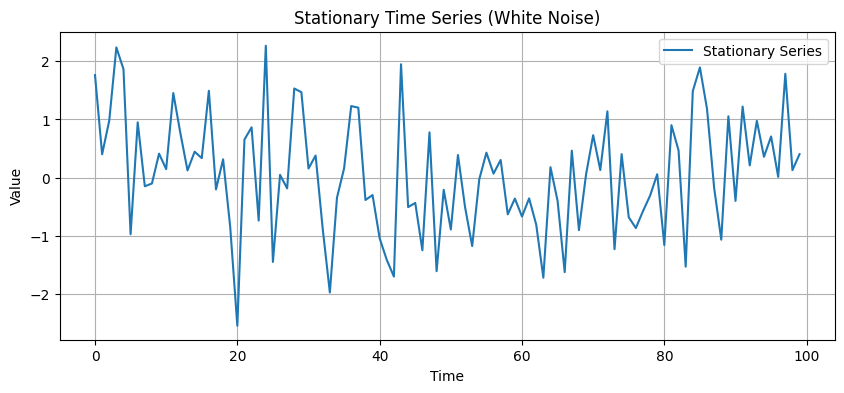

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 100
stationary_series = np.random.normal(loc=0.0, scale=1.0, size=n)

plt.figure(figsize=(10, 4))
plt.plot(stationary_series, label="Stationary Series")
plt.title("Stationary Time Series (White Noise)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


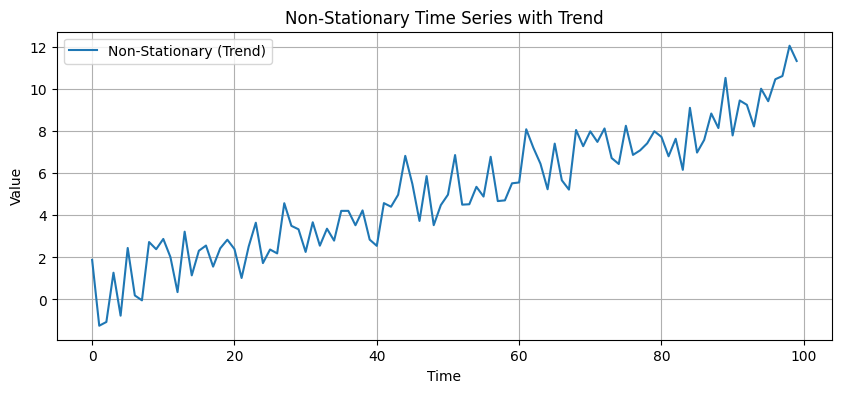

In [ ]:
trend = np.linspace(0, 10, n)
non_stationary_trend = trend + np.random.normal(0, 1, n)

plt.figure(figsize=(10, 4))
plt.plot(non_stationary_trend, label="Non-Stationary (Trend)")
plt.title("Non-Stationary Time Series with Trend")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


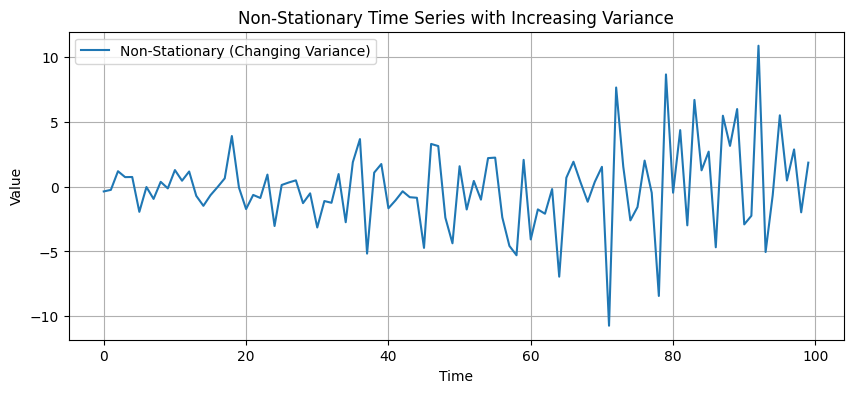

In [ ]:
variance = np.linspace(1, 5, n)
non_stationary_variance = np.random.normal(0, variance)

plt.figure(figsize=(10, 4))
plt.plot(non_stationary_variance, label="Non-Stationary (Changing Variance)")
plt.title("Non-Stationary Time Series with Increasing Variance")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


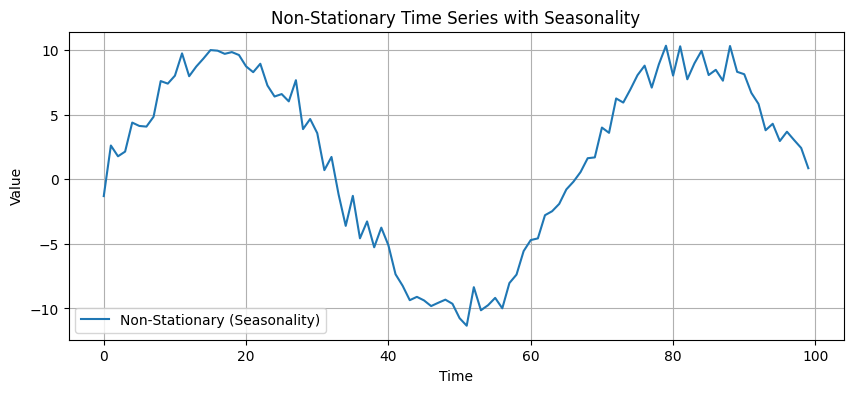

In [ ]:
seasonality = 10 * np.sin(np.linspace(0, 3 * np.pi, n))
non_stationary_seasonality = seasonality + np.random.normal(0, 1, n)

plt.figure(figsize=(10, 4))
plt.plot(non_stationary_seasonality, label="Non-Stationary (Seasonality)")
plt.title("Non-Stationary Time Series with Seasonality")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


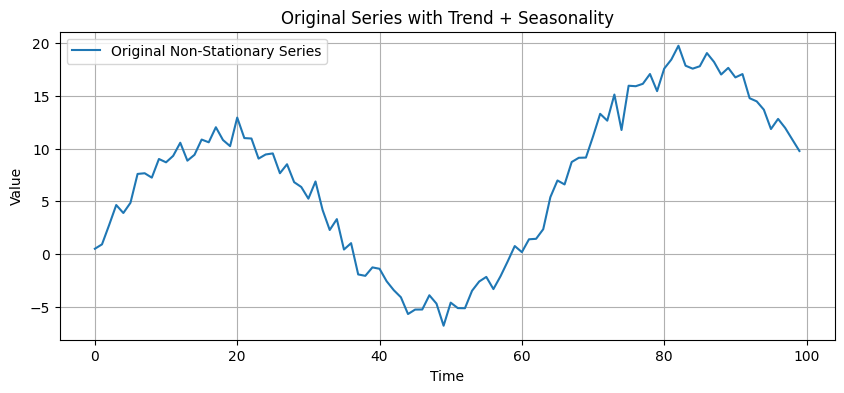

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100
trend = np.linspace(0, 10, n)
seasonal = 10 * np.sin(np.linspace(0, 3 * np.pi, n))
noise = np.random.normal(0, 1, n)

non_stationary = trend + seasonal + noise

plt.figure(figsize=(10, 4))
plt.plot(non_stationary, label="Original Non-Stationary Series")
plt.title("Original Series with Trend + Seasonality")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


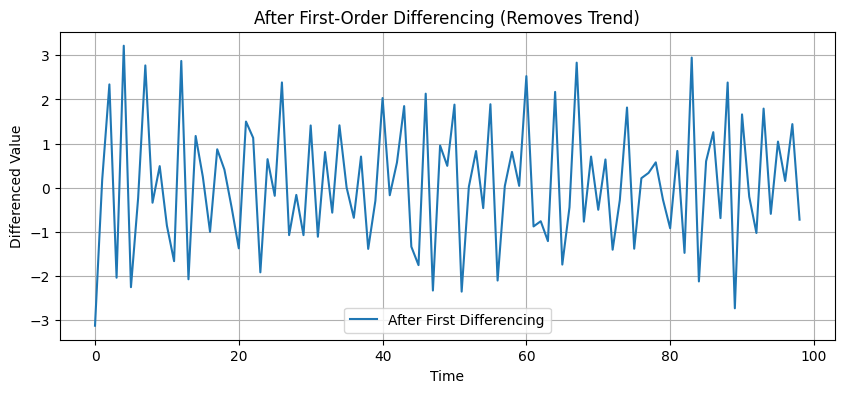

In [ ]:
first_diff = np.diff(non_stationary_trend)

plt.figure(figsize=(10, 4))
plt.plot(first_diff, label="After First Differencing")
plt.title("After First-Order Differencing (Removes Trend)")
plt.xlabel("Time")
plt.ylabel("Differenced Value")
plt.legend()
plt.grid(True)
plt.show()


**ADF Test of Stationarity**

The ADF test (Augmented Dickey-Fuller test) is a statistical test used to check if a time series is stationary—that is, whether its properties like mean and variance are constant over time.

Null Hypothesis: Data is not stationary

If p-value < 0.05:

- We reject the null hypothesis and conclude that the data is stationary.

If p-value > 0.05:
- We fail to reject the null hypothesis and conclude that the data is not stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(stationary_series)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -9.298574759765579
p-value: 1.1285451053950947e-15


**As** p< 0.05 we reject null hypothesis and consider that data is stationary

In [ ]:
## ADF test on difference
result_diff = adfuller(first_diff)
print("ADF Statistic after differencing:", result_diff[0])
print("p-value after differencing:", result_diff[1])

ADF Statistic after differencing: -5.98717653927435
p-value after differencing: 1.7807364360099877e-07


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Step 1: ADF Test
result = adfuller(df['Passengers'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Step 2: Differencing if p > 0.05
df_diff = df['Passengers'].diff().dropna()
result_diff = adfuller(df_diff)
print("ADF after differencing:", result_diff[0])
print("p-value after differencing:", result_diff[1])


ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
ADF after differencing: -2.8292668241700047
p-value after differencing: 0.05421329028382478


# ARIMA
AutoRegressive Integrated Moving Average

It is a popular forecasting model used in time series analysis, especially when data shows trends but no strong seasonality.

## Components of ARIMA(p, d, q)

- **p – AutoRegressive (AR)**:  
  Uses past values to predict the current value.

- **d – Integrated (I)**:  
  Represents the number of differencing steps needed to make the series stationary.

- **q – Moving Average (MA)**:  
  Uses past forecast errors to predict the current value.



 Example:  
If your model is ARIMA(1,1,1), it means:

- 1 lag of past values (AR)
- 1 differencing to make it stationary (I)
- 1 lag of past forecast errors (MA)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Fri, 25 Apr 2025   AIC                           1394.683
Time:                        17:19:30   BIC                           1403.571
Sample:                    01-01-1949   HQIC                          1398.294
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

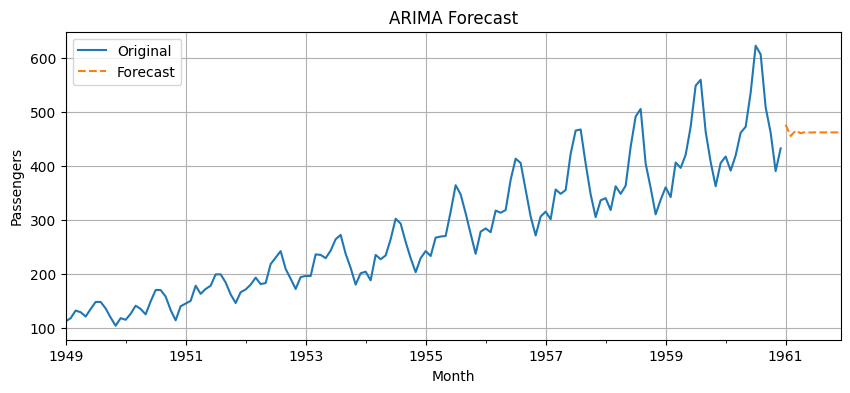

In [ ]:

# Step 3: Fit ARIMA
model = ARIMA(df['Passengers'], order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

# Step 4: Forecast
forecast = model_fit.forecast(steps=12)

# Plot
plt.figure(figsize=(10, 4))
df['Passengers'].plot(label='Original')
forecast.plot(label='Forecast', linestyle='--')
plt.title('ARIMA Forecast')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()


##  What is SARIMA?

**SARIMA** stands for:  
**Seasonal AutoRegressive Integrated Moving Average**

It’s an extension of the ARIMA model that also handles **seasonality** in time series data.

---

## SARIMA Model Notation

**SARIMA(p, d, q)(P, D, Q, s)**

- `(p, d, q)` → Regular (non-seasonal) ARIMA components  
- `(P, D, Q, s)` → Seasonal components

Where:
- **P**: Seasonal AutoRegressive (SAR) terms  
- **D**: Seasonal differencing  
- **Q**: Seasonal Moving Average (SMA) terms  
- **s**: Season length (e.g., 12 for monthly data with yearly seasonality)

---

## When to Use SARIMA?

Use **SARIMA** when:

- Your time series shows **seasonal patterns** (e.g., sales peak every December)
- ARIMA does not perform well due to **recurring cycles**

---

## Example

For **monthly airline passenger data** with yearly seasonality, a model like:

**SARIMA(1,1,1)(1,1,1,12)**

Means:

- `ARIMA(1,1,1)`: captures basic trend
- `SARIMA(1,1,1,12)`: accounts for yearly seasonal effects (every 12 months)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -456.103
Date:                            Fri, 25 Apr 2025   AIC                            922.205
Time:                                    17:35:16   BIC                            936.016
Sample:                                01-01-1949   HQIC                           927.812
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2298      0.401     -0.573      0.567      -1.016       0.557
ma.L1         -0.0987      0.374   

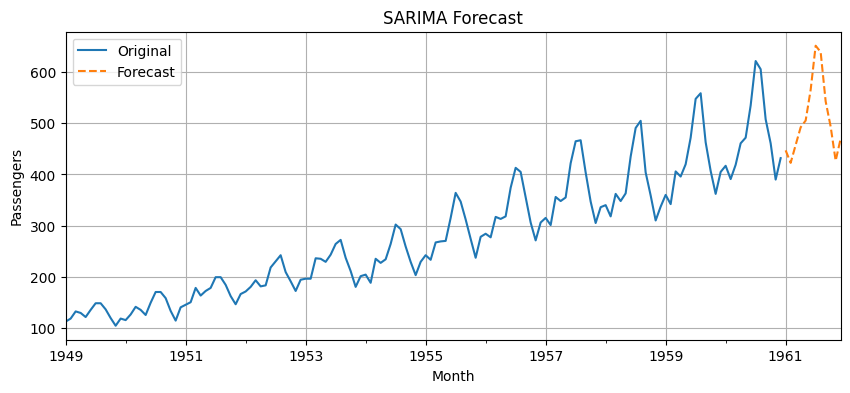

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['Passengers'],
                order=(1,1,1),        # ARIMA part
                seasonal_order=(1,1,1,12),  # Seasonal part
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit()
print(model_fit.summary())

# Step 4: Forecast
s_forecast = model_fit.forecast(steps=12)

# Plot
plt.figure(figsize=(10, 4))
df['Passengers'].plot(label='Original')
s_forecast.plot(label='Forecast', linestyle='--')
plt.title('SARIMA Forecast')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Energy dataset with temperature, humidity and energy consumption
url = "https://raw.githubusercontent.com/Naga-kiran/time-series-datasets/main/energydata_complete.csv"
df_multi = pd.read_csv(url, parse_dates=['date'], index_col='date')

df_multi = df_multi[['Appliances', 'T_out', 'RH_out']]  # Select relevant variables
df_multi = df_multi.resample('D').mean().dropna()  # Daily average to reduce noise

df_multi.plot(figsize=(14, 6), title='🏠 Energy Usage vs Temperature and Humidity')
plt.grid(True)
plt.show()

df_multi.head()


HTTPError: HTTP Error 404: Not Found